# ResNet50 Ordinal Regression for Diabetic Retinopathy Grading

**Goal:** Replicate the Kaggle ResNet50 approach (ordinal regression + QWK optimization)
using our M3 retinal dataset in PyTorch.

**Target:** QWK > 0.80 on validation set.

**Approach:**
- ResNet50 pretrained on ImageNet
- Ordinal regression (single neuron output + MSE loss → discretize to 5 classes)
- Gradual unfreezing (3 phases)
- Quadratic Weighted Kappa as primary evaluation metric
- OptimizedRounder for threshold tuning

In [1]:
import os
import sys
import json
import copy
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from scipy.optimize import minimize

print(f'PyTorch: {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch: 2.1.0+cu118
torchvision: 0.16.0+cu118
CUDA available: True
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design
VRAM: 4.29 GB


---
## 1. Configuration

In [2]:
# Reproducibility
SEED = 2019
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Paths
DATA_DIR = os.path.join('..', '..', 'data', 'processed', 'M3_diagnosis')
CSV_TRAIN = os.path.join(DATA_DIR, 'labels_train.csv')
CSV_VAL = os.path.join(DATA_DIR, 'labels_val.csv')
CSV_TEST = os.path.join(DATA_DIR, 'labels_test.csv')
IMG_DIR = os.path.join(DATA_DIR, 'images')

# Verify paths exist
for p in [DATA_DIR, IMG_DIR]:
    os.makedirs(p, exist_ok=True)
for p, name in [(CSV_TRAIN, 'train'), (CSV_VAL, 'val'), (CSV_TEST, 'test')]:
    if os.path.exists(p):
        df_tmp = pd.read_csv(p)
        print(f'{name}: {len(df_tmp)} samples - {p}')
    else:
        print(f'{name}: NOT FOUND - {p}')

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 16
LR_HEAD = 1e-3
LR_FULL = 1e-4
LR_FINETUNE = 1e-5
WEIGHT_DECAY = 1e-6
NUM_CLASSES = 5
NUM_WORKERS = 0

# Phase epochs
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 20
EPOCHS_PHASE3 = 30

# Model save path
MODEL_SAVE_DIR = os.path.join('..', 'models', 'classification')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, 'resnet50_best.pth')

print(f'\nConfiguration:')
print(f'  Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Phase 1 (head only): {EPOCHS_PHASE1} epochs, LR={LR_HEAD}')
print(f'  Phase 2 (last layers): {EPOCHS_PHASE2} epochs, LR={LR_FULL}')
print(f'  Phase 3 (full): {EPOCHS_PHASE3} epochs, LR={LR_FINETUNE}')

Using device: cuda
train: 2504 samples - ..\..\data\processed\M3_diagnosis\labels_train.csv
val: 537 samples - ..\..\data\processed\M3_diagnosis\labels_val.csv
test: 537 samples - ..\..\data\processed\M3_diagnosis\labels_test.csv

Configuration:
  Image size: 224x224
  Batch size: 16
  Phase 1 (head only): 10 epochs, LR=0.001
  Phase 2 (last layers): 20 epochs, LR=0.0001
  Phase 3 (full): 30 epochs, LR=1e-05


---
## 2. Preprocessing Functions

Adapted from the Kaggle ResNet50 notebook:
- Crop dark borders from retinal fundus images
- Contrast enhancement via `addWeighted`
- Resize to 224x224

Preprocessing functions defined.
Test: find an image...
  Test image: 000c1434d8d7.png
  Shape: (224, 224, 3)
  Range: [0, 255]


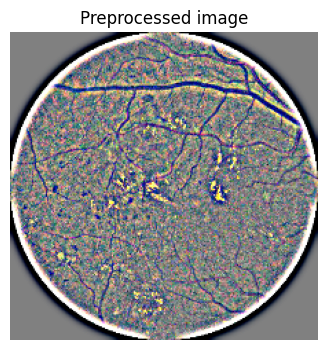

In [3]:
def crop_image_from_gray(img, tol=7):
    return img


def contrast_enhancement(img):
    """
    Apply contrast enhancement using addWeighted.
    Equivalent to: img * 4 - blurred * 4 + 128
    """
    blur_size = IMG_SIZE // 30
    if blur_size % 2 == 0:
        blur_size += 1
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=IMG_SIZE / 30)
    enhanced = cv2.addWeighted(img, 4, blurred, -4, 128)
    return enhanced


def preprocess_image(img_path):
    """
    Full preprocessing pipeline:
    1. Load image
    2. Convert BGR -> RGB
    3. Crop dark borders
    4. Contrast enhancement
    5. Resize to IMG_SIZE
    """
    img = cv2.imread(str(img_path))
    if img is None:
        raise FileNotFoundError(f'Cannot load image: {img_path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image_from_gray(img, tol=7)
    img = contrast_enhancement(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    return img


# Test preprocessing on one image
print('Preprocessing functions defined.')
print('Test: find an image...')
if os.path.exists(IMG_DIR):
    test_imgs = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if test_imgs:
        test_path = os.path.join(IMG_DIR, test_imgs[0])
        test_img = preprocess_image(test_path)
        print(f'  Test image: {test_imgs[0]}')
        print(f'  Shape: {test_img.shape}')
        print(f'  Range: [{test_img.min()}, {test_img.max()}]')
        
        plt.figure(figsize=(4, 4))
        plt.imshow(test_img)
        plt.title('Preprocessed image')
        plt.axis('off')
        plt.show()
    else:
        print('  No images found in IMG_DIR')
else:
    print(f'  IMG_DIR does not exist: {IMG_DIR}')

---
## 3. Dataset Class

Loads images from disk, applies preprocessing and augmentation.
Returns (image, label) where label is a float for ordinal regression.

In [4]:
class RetinalDataset(Dataset):
    """
    Dataset for ordinal regression on retinal images.
    
    Labels are returned as float32 for MSE regression.
    Augmentation is applied only to training set.
    """
    def __init__(self, csv_path, img_dir, transform=None, is_train=False):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.is_train = is_train
        
        # Ensure columns exist
        if 'id_code' in self.df.columns:
            self.id_col = 'id_code'
        elif 'image_id' in self.df.columns:
            self.id_col = 'image_id'
        else:
            self.id_col = self.df.columns[0]
        
        if 'diagnosis' in self.df.columns:
            self.label_col = 'diagnosis'
        else:
            self.label_col = self.df.columns[1]
        
        # Train/val transforms
        self.train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(160),
            transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0), ratio=(0.8, 1.2)),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
        
        self.val_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])
        label = float(row[self.label_col])
        
        # Try common extensions
        img_path = None
        for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG']:
            candidate = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        
        if img_path is None:
            # Try without extension (filename may already include it)
            candidate = os.path.join(self.img_dir, img_id)
            if os.path.exists(candidate):
                img_path = candidate
        
        if img_path is None:
            raise FileNotFoundError(f'Image not found: {img_id} in {self.img_dir}')
        
        img = preprocess_image(img_path)
        
        # Apply transforms
        if self.is_train:
            img_pil = Image.fromarray(img.astype(np.uint8))
            img_tensor = self.train_transform(img_pil)
        else:
            img_tensor = self.val_transform(img)
        
        return img_tensor, torch.tensor(label, dtype=torch.float32)


print('RetinalDataset class defined.')
print(f'CSV columns: id_code, diagnosis')

RetinalDataset class defined.
CSV columns: id_code, diagnosis


---
## 4. Model Definition

ResNet50 pretrained on ImageNet with ordinal regression head:
```
ResNet50 (conv features) → GAP → Dropout(0.5) → Linear(2048, 1)
```
Single output neuron with linear activation → MSE loss → threshold to class labels.

In [5]:
def build_resnet50_ordinal():
    """
    Build ResNet50 with ordinal regression head.
    
    Architecture:
        ResNet50 (ImageNet pretrained) → GlobalAvgPool → Dropout(0.5) → Linear(2048, 1)
    """
    # Load pretrained ResNet50
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    
    # Remove original classifier
    in_features = model.fc.in_features  # 2048
    
    # Add ordinal regression head
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 1)
    )
    
    return model


model = build_resnet50_ordinal()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: ResNet50 Ordinal')
print(f'  Total parameters: {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,}')
print(f'  Output: 1 neuron (ordinal regression)')

Model: ResNet50 Ordinal
  Total parameters: 23,510,081
  Trainable parameters: 23,510,081
  Output: 1 neuron (ordinal regression)


---
## 5. Metrics: QWK and OptimizedRounder

**Quadratic Weighted Kappa (QWK):** Primary evaluation metric.
Measures agreement between predicted and true ordinal classes,
penalizing larger disagreements more heavily.

**OptimizedRounder:** Finds optimal threshold boundaries for
converting continuous predictions to class labels, maximizing QWK.

In [6]:
def quadratic_weighted_kappa(y_true, y_pred):
    """
    Compute Quadratic Weighted Kappa between true and predicted labels.
    
    Ranges from -1 (worst) to 1 (perfect).
    0 = random agreement.
    """
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


def predict_classes(model, dataloader, device, thresholds=None):
    """
    Predict class labels from ordinal regression model.
    
    Args:
        model: ResNet50 ordinal regression model
        dataloader: DataLoader with images
        device: 'cuda' or 'cpu'
        thresholds: List of 4 boundaries [t1, t2, t3, t4].
                    If None, uses [0.5, 1.5, 2.5, 3.5].
    
    Returns:
        y_true: numpy array of true labels
        y_pred: numpy array of predicted class labels
        y_raw: numpy array of raw continuous predictions
    """
    if thresholds is None:
        thresholds = [0.5, 1.5, 2.5, 3.5]
    
    model.eval()
    y_true_list = []
    y_pred_raw = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images).squeeze()
            y_true_list.extend(labels.cpu().numpy())
            y_pred_raw.extend(outputs.cpu().numpy())
    
    y_true = np.array(y_true_list)
    y_raw = np.array(y_pred_raw)
    
    # Discretize using thresholds
    y_pred = np.zeros_like(y_raw, dtype=int)
    for i, th in enumerate(thresholds):
        y_pred[y_raw > th] = i + 1
    
    # Clip to [0, 4]
    y_pred = np.clip(y_pred, 0, 4)
    
    return y_true, y_pred, y_raw


def compute_qwk(model, dataloader, device, thresholds=None):
    """Compute QWK score for model on given dataloader."""
    y_true, y_pred, _ = predict_classes(model, dataloader, device, thresholds)
    return quadratic_weighted_kappa(y_true, y_pred)


class OptimizedRounder:
    """
    Find optimal threshold boundaries to maximize QWK.
    
    Uses Nelder-Mead optimization to adjust the 4 boundaries
    between classes 0-1, 1-2, 2-3, 3-4.
    """
    def __init__(self):
        self.coefficients_ = None
    
    def _loss(self, coefficients, y_true, y_pred):
        """Negative QWK (for minimization)."""
        y_pred_class = np.zeros_like(y_pred, dtype=int)
        for i, th in enumerate(coefficients):
            y_pred_class[y_pred > th] = i + 1
        y_pred_class = np.clip(y_pred_class, 0, 4)
        return -quadratic_weighted_kappa(y_true, y_pred_class)
    
    def fit(self, y_pred, y_true):
        """
        Fit optimal thresholds.
        
        Args:
            y_pred: Raw continuous predictions
            y_true: True class labels
        """
        initial_coef = [0.5, 1.5, 2.5, 3.5]
        bounds = [(-0.5, 1.5), (0.5, 2.5), (1.5, 3.5), (2.5, 5.0)]
        
        result = minimize(
            self._loss,
            initial_coef,
            args=(y_true, y_pred),
            method='Nelder-Mead',
            options={'maxiter': 1000, 'xatol': 1e-8, 'fatol': 1e-8}
        )
        
        self.coefficients_ = result.x
        return self.coefficients_
    
    def predict(self, y_pred, coefficients=None):
        """Predict classes using fitted thresholds."""
        if coefficients is None:
            if self.coefficients_ is None:
                raise ValueError('Must call fit() before predict()')
            coefficients = self.coefficients_
        
        y_pred_class = np.zeros_like(y_pred, dtype=int)
        for i, th in enumerate(coefficients):
            y_pred_class[y_pred > th] = i + 1
        y_pred_class = np.clip(y_pred_class, 0, 4)
        return y_pred_class


print('Metrics and OptimizedRounder defined.')
print(f'Test QWK (random): {quadratic_weighted_kappa(np.array([0,1,2]), np.array([0,2,1])):.4f}')

Metrics and OptimizedRounder defined.
Test QWK (random): 0.5000


---
## 6. Training Functions

Includes:
- `train_epoch`: Single training epoch
- `validate_epoch`: Single validation epoch
- QWK callback: tracks best validation QWK

In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train model for one epoch.
    
    Returns:
        avg_loss: Average training loss
    """
    model.train()
    running_loss = 0.0
    num_batches = 0
    
    pbar = tqdm(dataloader, desc='Train', leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return running_loss / num_batches


@torch.no_grad()
def validate_epoch(model, dataloader, criterion, device):
    """
    Validate model for one epoch.
    
    Returns:
        avg_loss: Average validation loss
        qwk: QWK score with default thresholds
        y_true: All true labels
        y_pred: All raw predictions
    """
    model.eval()
    running_loss = 0.0
    num_batches = 0
    all_labels = []
    all_preds = []
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        num_batches += 1
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.cpu().numpy())
    
    avg_loss = running_loss / num_batches
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Compute QWK with default thresholds
    thresholds = [0.5, 1.5, 2.5, 3.5]
    y_pred_class = np.zeros_like(y_pred, dtype=int)
    for i, th in enumerate(thresholds):
        y_pred_class[y_pred > th] = i + 1
    y_pred_class = np.clip(y_pred_class, 0, 4)
    
    qwk = quadratic_weighted_kappa(y_true, y_pred_class)
    
    return avg_loss, qwk, y_true, y_pred


def set_requires_grad(model, layers_to_unfreeze=None):
    """
    Control which layers require gradients.
    
    Args:
        model: ResNet50 model
        layers_to_unfreeze: Number of top layers to unfreeze (None = freeze all)
    """
    if layers_to_unfreeze is None:
        # Freeze everything except fc (Phase 1)
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True
    elif layers_to_unfreeze == 'last':
        # Unfreeze layer4 + fc (Phase 2)
        for name, param in model.named_parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if 'layer4' in name or 'fc' in name:
                param.requires_grad = True
    else:
        # Unfreeze all (Phase 3)
        for param in model.parameters():
            param.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


print('Training functions defined.')

Training functions defined.


---
## 7. Load Data

Create datasets and dataloaders from the M3 splits.

In [8]:
# Create datasets
print('Creating datasets...')

if not os.path.exists(CSV_TRAIN):
    print(f'Training CSV not found: {CSV_TRAIN}')
    print('Creating train/val/test split from unified CSV...')
    unified_csv = os.path.join(DATA_DIR, 'labels_cleaned.csv')
    if os.path.exists(unified_csv):
        df = pd.read_csv(unified_csv)
        print(f'  Loaded {len(df)} samples from unified CSV')
        
        from sklearn.model_selection import train_test_split
        
        # Stratified split: 70% train, 15% val, 15% test
        train_df, temp_df = train_test_split(
            df, test_size=0.3, random_state=SEED, stratify=df['diagnosis']
        )
        val_df, test_df = train_test_split(
            temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['diagnosis']
        )
        
        train_df.to_csv(CSV_TRAIN, index=False)
        val_df.to_csv(CSV_VAL, index=False)
        test_df.to_csv(CSV_TEST, index=False)
        
        print(f'  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
    else:
        print(f'  Unified CSV not found either: {unified_csv}')
        print('  Please prepare the dataset first using model_preparation.ipynb')
        raise FileNotFoundError('No dataset found')

# Create datasets
train_dataset = RetinalDataset(CSV_TRAIN, IMG_DIR, is_train=True)
val_dataset = RetinalDataset(CSV_VAL, IMG_DIR, is_train=False)
test_dataset = RetinalDataset(CSV_TEST, IMG_DIR, is_train=False)

print(f'\nDataset sizes:')
print(f'  Train: {len(train_dataset)}')
print(f'  Val:   {len(val_dataset)}')
print(f'  Test:  {len(test_dataset)}')

# Create dataloaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True if device=='cuda' else False
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True if device=='cuda' else False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True if device=='cuda' else False
)

# Show class distribution
train_df = pd.read_csv(CSV_TRAIN)
print('\nTrain class distribution:')
for c in range(5):
    count = (train_df['diagnosis'] == c).sum()
    print(f'  Class {c}: {count} ({count/len(train_df)*100:.1f}%)')

Creating datasets...

Dataset sizes:
  Train: 2504
  Val:   537
  Test:  537

Train class distribution:
  Class 0: 1262 (50.4%)
  Class 1: 245 (9.8%)
  Class 2: 668 (26.7%)
  Class 3: 127 (5.1%)
  Class 4: 202 (8.1%)


---
## 8. Training Loop

Three-phase gradual unfreezing:
1. **Phase 1**: Head only (FC layer) — 10 epochs
2. **Phase 2**: Unfreeze layer4 + head — 20 epochs  
3. **Phase 3**: Full fine-tune — 30 epochs

Best model saved by validation QWK.

In [9]:
def train_phase(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, num_epochs, phase_name, best_qwk):
    """
    Train model for a phase.
    
    Returns:
        phase_best_qwk: Best QWK achieved in this phase
        history: Dict of losses and QWKs per epoch
    """
    print(f'\n{"="*60}')
    print(f'  PHASE: {phase_name}')
    print(f'{"="*60}')
    
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': []}
    best_val_qwk = max(best_qwk, -1.0)
    
    for epoch in range(1, num_epochs + 1):
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_qwk, _, _ = validate_epoch(model, val_loader, criterion, device)
        
        # Scheduler step
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # Track history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        
        # Save best model
        if val_qwk > best_val_qwk:
            best_val_qwk = val_qwk
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_qwk': val_qwk,
                'val_loss': val_loss,
                'train_loss': train_loss,
                'phase': phase_name
            }, MODEL_SAVE_PATH)
            print(f'  >>> Saved new best model (QWK={val_qwk:.4f})')
        
        # Log progress
        if epoch == 1 or epoch % 5 == 0 or epoch == num_epochs:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch:2d}/{num_epochs} | '
                  f'Train Loss: {train_loss:.4f} | '
                  f'Val Loss: {val_loss:.4f} | '
                  f'Val QWK: {val_qwk:.4f} | '
                  f'LR: {current_lr:.2e}')
    
    print(f'  Best Val QWK: {best_val_qwk:.4f}')
    return best_val_qwk, history


print('Training loop ready.')
print(f'Best model will be saved to: {MODEL_SAVE_PATH}')

Training loop ready.
Best model will be saved to: ..\models\classification\resnet50_best.pth


---
## 9. Execute Training

Run the three-phase training. Total: ~60 epochs.

In [10]:
# Initialize fresh model
model = build_resnet50_ordinal()
model = model.to(device)
criterion = nn.MSELoss()

best_qwk = -1.0
all_history = {}

# === PHASE 1: Train head only ===
print('\nStep 1: Freezing backbone, training head only...')
trainable, total = set_requires_grad(model, layers_to_unfreeze=None)
print(f'  Trainable params: {trainable:,} / {total:,}')

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

best_qwk, hist_p1 = train_phase(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, EPOCHS_PHASE1, 'Phase 1: Head Only (LR=1e-3)', best_qwk
)
all_history['phase1'] = hist_p1

# === PHASE 2: Unfreeze layer4 ===
print('\nStep 2: Unfreezing layer4 + head...')
trainable, total = set_requires_grad(model, layers_to_unfreeze='last')
print(f'  Trainable params: {trainable:,} / {total:,}')

# Reload best model from phase 1 to continue from there
if os.path.exists(MODEL_SAVE_PATH):
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'  Loaded best model from phase {checkpoint["phase"]}')

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': LR_FULL * 0.5},
    {'params': model.fc.parameters(), 'lr': LR_FULL}
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4, verbose=True
)

best_qwk, hist_p2 = train_phase(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, EPOCHS_PHASE2, 'Phase 2: Layer4 + Head (LR=1e-4)', best_qwk
)
all_history['phase2'] = hist_p2

# === PHASE 3: Full fine-tune ===
print('\nStep 3: Full fine-tune...')
trainable, total = set_requires_grad(model, layers_to_unfreeze='all')
print(f'  Trainable params: {trainable:,} / {total:,}')

if os.path.exists(MODEL_SAVE_PATH):
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'  Loaded best model from phase {checkpoint["phase"]}')

optimizer = optim.Adam(
    model.parameters(),
    lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True,
    min_lr=1e-7
)

best_qwk, hist_p3 = train_phase(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, EPOCHS_PHASE3, 'Phase 3: Full Fine-tune (LR=1e-5)', best_qwk
)
all_history['phase3'] = hist_p3

print(f'\n{"="*60}')
print(f'  TRAINING COMPLETE')
print(f'  Best Validation QWK: {best_qwk:.4f}')
print(f'  Model saved: {MODEL_SAVE_PATH}')
print(f'{"="*60}')


Step 1: Freezing backbone, training head only...
  Trainable params: 2,049 / 23,510,081

  PHASE: Phase 1: Head Only (LR=1e-3)


  >>> Saved new best model (QWK=0.6536)
  Epoch  1/10 | Train Loss: 1.2884 | Val Loss: 0.8085 | Val QWK: 0.6536 | LR: 1.00e-03


  >>> Saved new best model (QWK=0.7037)


  Epoch  5/10 | Train Loss: 0.9836 | Val Loss: 0.8174 | Val QWK: 0.6725 | LR: 1.00e-03


Epoch 00006: reducing learning rate of group 0 to 5.0000e-04.


...

  >>> Saved new best model (QWK=0.8884)


  >>> Saved new best model (QWK=0.8920)
  Epoch 20/30 | Train Loss: 0.3252 | Val Loss: 0.3244 | Val QWK: 0.8920 | LR: 5.00e-06


  Epoch 25/30 | Train Loss: 0.3135 | Val Loss: 0.3298 | Val QWK: 0.8886 | LR: 5.00e-06


Epoch 00026: reducing learning rate of group 0 to 2.5000e-06.


  Epoch 30/30 | Train Loss: 0.2896 | Val Loss: 0.3313 | Val QWK: 0.8816 | LR: 2.50e-06
  Best Val QWK: 0.8920

  TRAINING COMPLETE
  Best Validation QWK: 0.8920
  Model saved: ..\models\classification\resnet50_best.pth


---
## 10. Training History Visualization

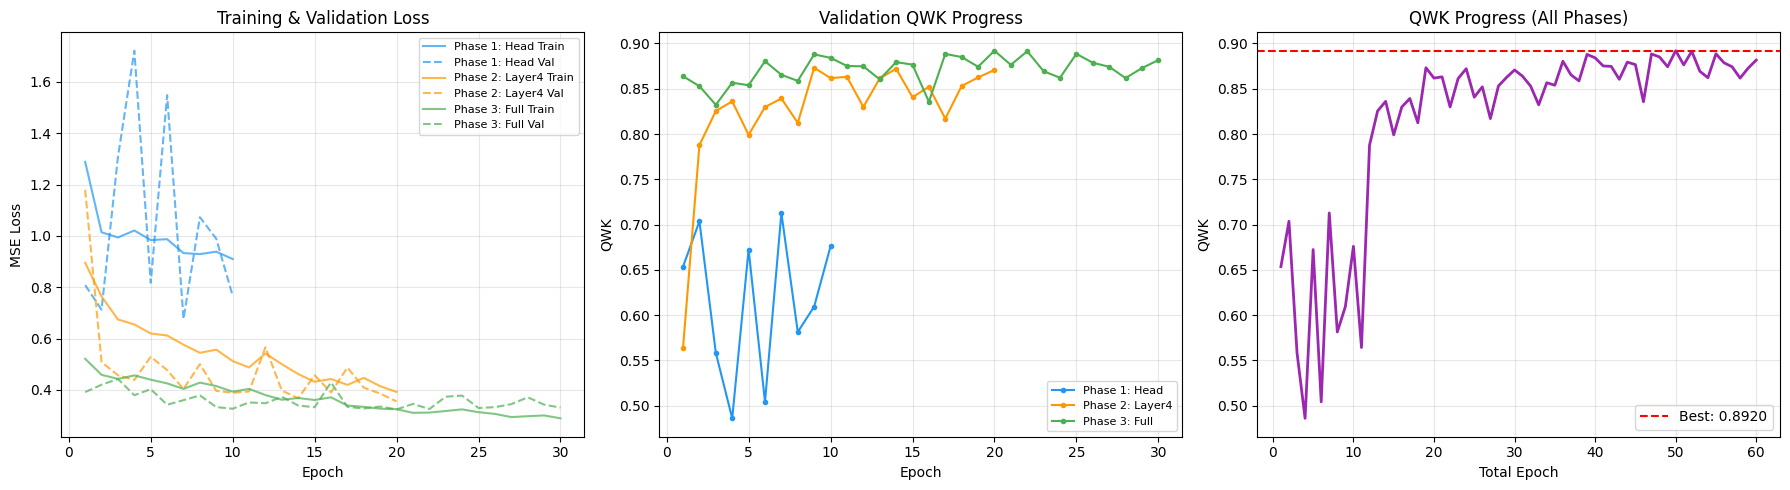

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2196F3', '#FF9800', '#4CAF50']
phase_names = ['Phase 1: Head', 'Phase 2: Layer4', 'Phase 3: Full']

for idx, (phase, hist) in enumerate(all_history.items()):
    epochs = range(1, len(hist['train_loss']) + 1)
    
    # Loss plot
    ax = axes[0]
    ax.plot(epochs, hist['train_loss'], color=colors[idx], linestyle='-',
            label=f'{phase_names[idx]} Train', alpha=0.7)
    ax.plot(epochs, hist['val_loss'], color=colors[idx], linestyle='--',
            label=f'{phase_names[idx]} Val', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Training & Validation Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # QWK plot
    ax = axes[1]
    ax.plot(epochs, hist['val_qwk'], color=colors[idx], marker='o',
            label=phase_names[idx], markersize=3)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('QWK')
    ax.set_title('Validation QWK Progress')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Combined view
all_qwks = []
for hist in all_history.values():
    all_qwks.extend(hist['val_qwk'])
ax = axes[2]
ax.plot(range(1, len(all_qwks) + 1), all_qwks, color='#9C27B0', linewidth=2)
ax.axhline(y=best_qwk, color='red', linestyle='--', label=f'Best: {best_qwk:.4f}')
ax.set_xlabel('Total Epoch')
ax.set_ylabel('QWK')
ax.set_title('QWK Progress (All Phases)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 11. Threshold Optimization with OptimizedRounder

Find optimal thresholds on validation set, apply to test set.

In [12]:
# Load best model
if os.path.exists(MODEL_SAVE_PATH):
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'Loaded best model from epoch {checkpoint["epoch"]}')
    print(f'  Val QWK: {checkpoint["val_qwk"]:.4f}')

# Get raw predictions on validation set
val_true, val_pred, val_raw = predict_classes(model, val_loader, device)

print(f'\nValidation predictions:')
print(f'  Raw range: [{val_raw.min():.3f}, {val_raw.max():.3f}]')
print(f'  Raw mean: {val_raw.mean():.3f}')
print(f'  Raw std: {val_raw.std():.3f}')

# Default thresholds
default_thresholds = [0.5, 1.5, 2.5, 3.5]
_, val_pred_default, _ = predict_classes(model, val_loader, device, default_thresholds)
default_qwk = quadratic_weighted_kappa(val_true, val_pred_default)
print(f'\nDefault thresholds {default_thresholds}:')
print(f'  QWK: {default_qwk:.4f}')
print(f'  Accuracy: {accuracy_score(val_true, val_pred_default):.4f}')

# Optimize thresholds
print('\nOptimizing thresholds with Nelder-Mead...')
optR = OptimizedRounder()
opt_coefficients = optR.fit(val_raw, val_true)

val_pred_opt = optR.predict(val_raw, opt_coefficients)
opt_qwk = quadratic_weighted_kappa(val_true, val_pred_opt)

print(f'\nOptimized thresholds:')
for i, coef in enumerate(opt_coefficients):
    print(f'  Class {i}-{i+1}: {coef:.4f} (default: {default_thresholds[i]:.4f})')
print(f'  QWK: {default_qwk:.4f} → {opt_qwk:.4f} (improvement: {opt_qwk - default_qwk:+.4f})')

Loaded best model from epoch 20
  Val QWK: 0.8920

Validation predictions:
  Raw range: [-0.329, 4.618]
  Raw mean: 1.049
  Raw std: 1.210

Default thresholds [0.5, 1.5, 2.5, 3.5]:
  QWK: 0.8920
  Accuracy: 0.7561

Optimizing thresholds with Nelder-Mead...

Optimized thresholds:
  Class 0-1: 0.5324 (default: 0.5000)
  Class 1-2: 1.5332 (default: 1.5000)
  Class 2-3: 2.3265 (default: 2.5000)
  Class 3-4: 3.5474 (default: 3.5000)
  QWK: 0.8920 → 0.9031 (improvement: +0.0111)


---
## 12. Full Evaluation on Test Set

In [13]:
print('='*60)
print('  TEST SET EVALUATION')
print('='*60)

# Get predictions on test set
test_true, test_pred_default, test_raw = predict_classes(model, test_loader, device, default_thresholds)
test_pred_opt = optR.predict(test_raw, opt_coefficients)

# Metrics with default thresholds
test_qwk_default = quadratic_weighted_kappa(test_true, test_pred_default)
test_acc_default = accuracy_score(test_true, test_pred_default)

# Metrics with optimized thresholds
test_qwk_opt = quadratic_weighted_kappa(test_true, test_pred_opt)
test_acc_opt = accuracy_score(test_true, test_pred_opt)

print(f'\n  Metrics Comparison:')
print(f'  {"Method":<25} {"QWK":>8} {"Accuracy":>10}')
print(f'  {"-"*45}')
print(f'  {"Default thresholds":<25} {test_qwk_default:>8.4f} {test_acc_default:>10.4f}')
print(f'  {"Optimized thresholds":<25} {test_qwk_opt:>8.4f} {test_acc_opt:>10.4f}')

# Use best thresholds
if test_qwk_opt > test_qwk_default:
    y_test_final = test_pred_opt
    final_qwk = test_qwk_opt
    final_acc = test_acc_opt
    final_thresholds = opt_coefficients
    print(f'  Using optimized thresholds (best QWK)')
else:
    y_test_final = test_pred_default
    final_qwk = test_qwk_default
    final_acc = test_acc_default
    final_thresholds = default_thresholds
    print(f'  Using default thresholds')

print(f'\n  FINAL TEST METRICS:')
print(f'  QWK:      {final_qwk:.4f}')
print(f'  Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)')
print(f'  Thresholds: {[f"{t:.4f}" for t in final_thresholds]}')

  TEST SET EVALUATION

  Metrics Comparison:
  Method                         QWK   Accuracy
  ---------------------------------------------
  Default thresholds          0.8711     0.7542
  Optimized thresholds        0.8764     0.7356
  Using optimized thresholds (best QWK)

  FINAL TEST METRICS:
  QWK:      0.8764
  Accuracy: 0.7356 (73.56%)
  Thresholds: ['0.5324', '1.5332', '2.3265', '3.5474']


---
## 13. Confusion Matrix & Per-Class Report

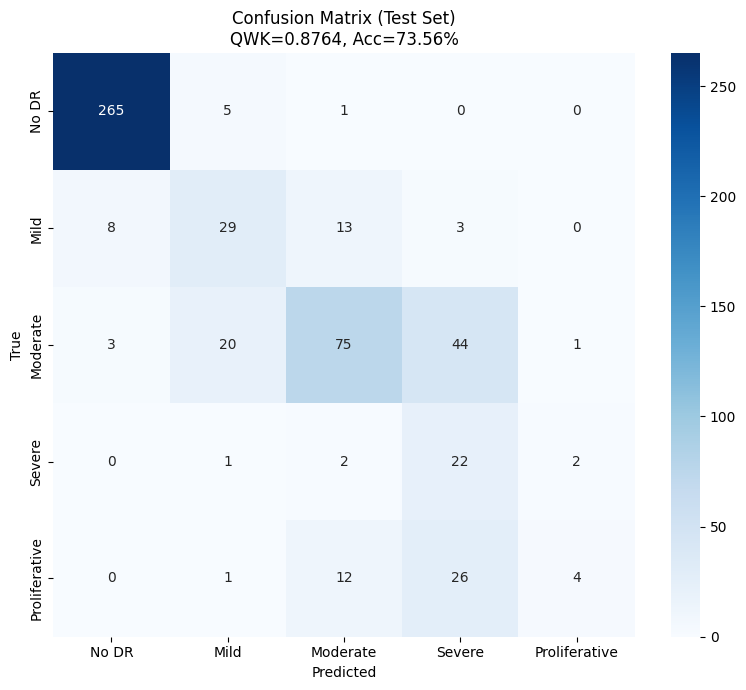


Classification Report:
               precision    recall  f1-score   support

        No DR     0.9601    0.9779    0.9689       271
         Mild     0.5179    0.5472    0.5321        53
     Moderate     0.7282    0.5245    0.6098       143
       Severe     0.2316    0.8148    0.3607        27
Proliferative     0.5714    0.0930    0.1600        43

     accuracy                         0.7356       537
    macro avg     0.6018    0.5915    0.5263       537
 weighted avg     0.7870    0.7356    0.7348       537


Binary Classification (DR vs No-DR):
  Accuracy:    0.9683
  QWK:         0.9367
  Sensitivity: 0.9586 (detecting DR)
  Specificity: 0.9779 (detecting healthy)


In [14]:
# Confusion matrix
cm = confusion_matrix(test_true, y_test_final)

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Test Set)\nQWK={final_qwk:.4f}, Acc={final_acc*100:.2f}%')
plt.tight_layout()
plt.show()

# Per-class report
print('\nClassification Report:')
print(classification_report(test_true, y_test_final,
      target_names=class_names, digits=4))

# Binary classification (DR vs No-DR)
test_binary_true = (test_true > 0).astype(int)
test_binary_pred = (y_test_final > 0).astype(int)
binary_acc = accuracy_score(test_binary_true, test_binary_pred)
binary_qwk = quadratic_weighted_kappa(test_binary_true, test_binary_pred)

tn, fp, fn, tp = confusion_matrix(test_binary_true, test_binary_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f'\nBinary Classification (DR vs No-DR):')
print(f'  Accuracy:    {binary_acc:.4f}')
print(f'  QWK:         {binary_qwk:.4f}')
print(f'  Sensitivity: {sensitivity:.4f} (detecting DR)')
print(f'  Specificity: {specificity:.4f} (detecting healthy)')

---
## 14. Comparison with VGG16 Baseline

In [15]:
print('Comparison: ResNet50 vs VGG16')
print('='*40)
print(f'{"Model":<20} {"Accuracy":>10} {"QWK":>8}')
print('-'*40)
print(f'{"VGG16 (Baseline)":<20} {"64.43%":>10} {"N/A":>8}')
print(f'{"ResNet50 (Ours)":<20} {final_acc*100:>9.2f}% {final_qwk:>8.4f}')

improvement = final_acc - 0.6443
print(f'\nImprovement over VGG16: {improvement*100:+.2f}%')
if improvement > 0:
    print('✓ ResNet50 outperforms VGG16 baseline!')
else:
    print('ResNet50 needs further tuning to surpass VGG16.')

Comparison: ResNet50 vs VGG16
Model                  Accuracy      QWK
----------------------------------------
VGG16 (Baseline)         64.43%      N/A
ResNet50 (Ours)          73.56%   0.8764

Improvement over VGG16: +9.13%
✓ ResNet50 outperforms VGG16 baseline!


---
## 15. Save Final Model & Results

In [16]:
# Save final model with all metadata
final_checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_qwk': best_qwk,
    'test_qwk': final_qwk,
    'test_accuracy': final_acc,
    'thresholds': final_thresholds.tolist() if isinstance(final_thresholds, np.ndarray) else final_thresholds,
    'architecture': 'ResNet50_Ordinal',
    'image_size': IMG_SIZE,
    'seed': SEED
}

torch.save(final_checkpoint, MODEL_SAVE_PATH)
print(f'Model saved: {MODEL_SAVE_PATH}')

# Save results summary
results = {
    'model': 'ResNet50_Ordinal',
    'val_qwk': float(best_qwk),
    'test_qwk': float(final_qwk),
    'test_accuracy': float(final_acc),
    'binary_accuracy': float(binary_acc),
    'sensitivity': float(sensitivity),
    'specificity': float(specificity),
    'thresholds': final_thresholds.tolist() if isinstance(final_thresholds, np.ndarray) else final_thresholds,
    'vgg16_baseline_accuracy': 0.6443
}

results_path = os.path.join(MODEL_SAVE_DIR, 'resnet50_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Results saved: {results_path}')

print(f'\n{"="*60}')
print(f'  FINAL SUMMARY')
print(f'{"="*60}')
print(f'  Model:      ResNet50 Ordinal Regression')
print(f'  Val QWK:    {best_qwk:.4f}')
print(f'  Test QWK:   {final_qwk:.4f}')
print(f'  Test Acc:   {final_acc*100:.2f}%')
print(f'  Thresholds: {final_thresholds}')
print(f'  VGG16 Acc:  64.43%')
print(f'  Δ:          {improvement*100:+.2f}%')

Model saved: ..\models\classification\resnet50_best.pth
Results saved: ..\models\classification\resnet50_results.json

  FINAL SUMMARY
  Model:      ResNet50 Ordinal Regression
  Val QWK:    0.8920
  Test QWK:   0.8764
  Test Acc:   73.56%
  Thresholds: [0.53244662 1.533231   2.32645979 3.54740328]
  VGG16 Acc:  64.43%
  Δ:          +9.13%
